In [32]:
import pandas as pd

# import data from csv-file
df = pd.read_csv("../data/output/events_combined.csv")

# split by source
df_tm = df[df['source'] == 'ticketmaster']
df_vs = df[df['source'] == 'visitstockholm']

df.head()

,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,Z698xZq2Z1k-Fudb3,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-14,18:00,onsale,Miscellaneous,Food & Drink,Restaurant,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Tuesday,April,4,2026,18.0,ticketmaster
1,Z698xZq2Z1k37ef-A,Eric Idle,https://www.ticketmaster.se/event/eric-idle-al...,https://s1.ticketm.net/dam/e/d88/0cbf49c5-f18e...,2026-04-14,19:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Tuesday,April,4,2026,19.0,ticketmaster
2,Z698xZq2Z16vZ0G9_M,40 Fingers,https://www.ticketmaster.se/event/40-fingers-b...,https://s1.ticketm.net/dam/e/a38/c01c9483-250c...,2026-04-15,19:30,onsale,Music,Rock,Pop,...,Stockholm,Götgatan 55,59.31378,18.07384,Wednesday,April,4,2026,19.0,ticketmaster
3,Z698xZq2Z16vavQaZx,Amanda Bergman,https://www.ticketmaster.se/event/amanda-bergm...,https://s1.ticketm.net/dam/a/da1/c489a12c-bab8...,2026-04-15,19:30,onsale,Music,Alternative,Indie Pop,...,Stockholm,Djurgårdsslätten 43-45,59.32457,18.09969,Wednesday,April,4,2026,19.0,ticketmaster
4,Z698xZq2Z16va-0gjy,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-16,18:00,onsale,Arts & Theatre,Theatre,Miscellaneous,...,Stockholm,Södermannagatan 27,59.31209,18.08133,Thursday,April,4,2026,18.0,ticketmaster


In [33]:
# Count the number of events per genre
df['genre'].value_counts()

genre
Jazz & Blues               229
Theatre                    190
Comedy                      87
Jazz/Klubb                  79
Culture & Arts              62
Rock                        57
Dance                       53
Film                        53
Other                       37
Food & Drink                30
Games & Championships       25
Hip-Hop/Rap                 19
Family                      17
Conventions & Fairs         14
Magic & Illusion            11
Dance/Electronic            10
Spectacular                  9
Classical                    6
Alternative                  5
Folk                         5
World                        4
Klubb/Konsert                4
Fairs & Festivals            3
Miscellaneous                3
Latin                        3
Children's Theatre           3
Blues                        2
Metal                        2
Soccer                       2
Martial Arts                 1
Reggae                       1
R&B                          1
Ci

In [34]:
df['source'].value_counts()

source
visitstockholm    575
ticketmaster      563
fasching           79
berns               4
Name: count, dtype: int64

In [35]:
# Find the top 3 dates with the highest number of events
df['date'].value_counts().nlargest(3)

date
2026-04-25    55
2026-04-20    45
2026-05-09    34
Name: count, dtype: int64

In [36]:
# Display top 10 most common venues
df['venue_name'].value_counts().nlargest(10)

venue_name
Cirkus                      83
Göta Lejon                  80
Fasching                    80
Tyrol                       72
Clarion Hotel Sign          51
Svartklubben                40
Debaser Nova                40
Debaser Strand              39
Avicii Arena                34
Dansens Hus - Stora Scen    29
Name: count, dtype: int64

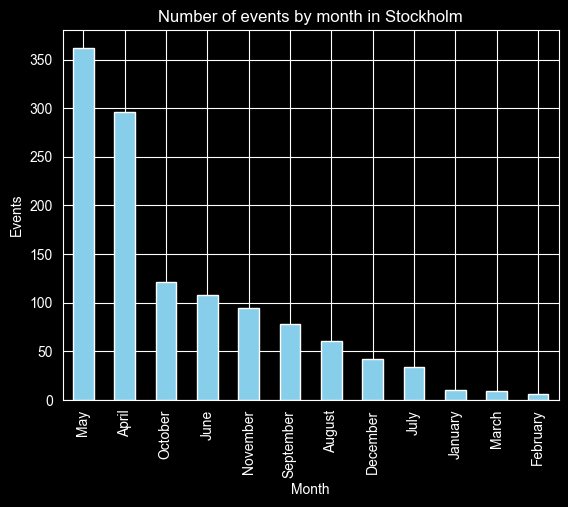

In [37]:
import matplotlib.pyplot as plt

# Count and visualize events per month using a bar chart
month_counts = df['month_name'].value_counts()

month_counts.plot(kind='bar', color='skyblue', edgecolor='white')

plt.title('Number of events by month in Stockholm')
plt.xlabel('Month')
plt.ylabel('Events')

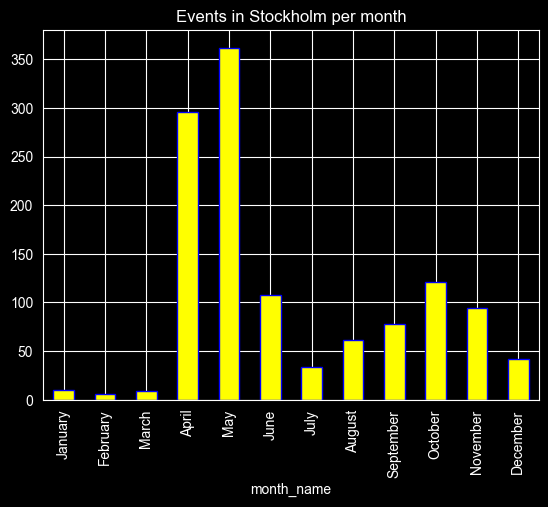

In [38]:
# Visualize events per month in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

counts = df['month_name'].value_counts()

counts_sorted = counts.reindex(month_order).dropna()

counts_sorted.plot(kind='bar', color='yellow', edgecolor='blue')
plt.title("Events in Stockholm per month")

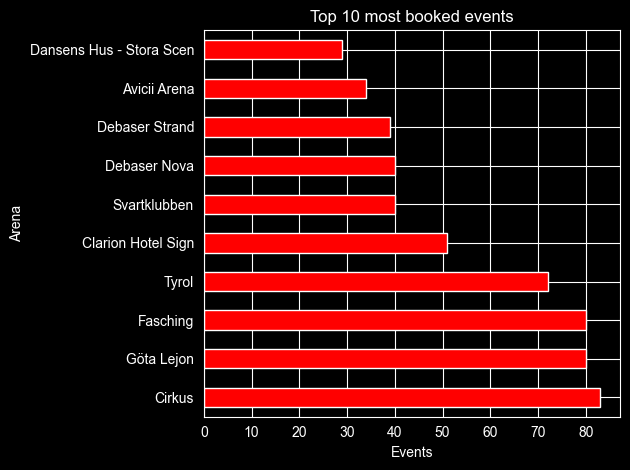

In [39]:
# Visualize the top 10 venues with the most events
venue_counts = df['venue_name'].value_counts()

top_10_venues = venue_counts.head(10)

top_10_venues.plot(kind='barh', color='red')

plt.title("Top 10 most booked events")
plt.xlabel("Events")
plt.ylabel('Arena')
plt.tight_layout()

In [40]:
import duckdb
# Query to count events by day of the week
duckdb.sql("""
SELECT day_of_week, COUNT(*) AS num_events
FROM df
GROUP BY day_of_week
ORDER BY num_events DESC
""")

┌─────────────┬────────────┐
│ day_of_week │ num_events │
│   varchar   │   int64    │
├─────────────┼────────────┤
│ Saturday    │        351 │
│ Friday      │        251 │
│ Thursday    │        171 │
│ Sunday      │        127 │
│ Wednesday   │        124 │
│ Monday      │        109 │
│ Tuesday     │         88 │
└─────────────┴────────────┘

In [41]:
# Find the top 5 venues with the most unique set of genres
duckdb.sql("""
SELECT venue_name, COUNT(DISTINCT genre) AS unique_genres
FROM df
WHERE venue_name IS NOT NULL
GROUP BY venue_name
ORDER BY unique_genres DESC
LIMIT 5
""")

┌──────────────────────────────┬───────────────┐
│          venue_name          │ unique_genres │
│           varchar            │     int64     │
├──────────────────────────────┼───────────────┤
│ Cirkus                       │            15 │
│ Göta Lejon                   │            12 │
│ Filadelfia Convention Center │            10 │
│ Rival                        │             9 │
│ Strawberry Arena             │             8 │
└──────────────────────────────┴───────────────┘

In [42]:
# Count events grouped by month and segment
duckdb.sql("""
SELECT month_name, segment, COUNT(*) AS num_events
FROM df
GROUP BY month_name, segment
ORDER BY month_name, num_events DESC
""")

┌────────────┬────────────────┬────────────┐
│ month_name │    segment     │ num_events │
│  varchar   │    varchar     │   int64    │
├────────────┼────────────────┼────────────┤
│ April      │ Arts & Theatre │        168 │
│ April      │ Music          │         69 │
│ April      │ Miscellaneous  │         39 │
│ April      │ Nightlife      │         15 │
│ April      │ Sports         │          5 │
│ August     │ Music          │         32 │
│ August     │ Arts & Theatre │         15 │
│ August     │ Sports         │          7 │
│ August     │ Nightlife      │          6 │
│ August     │ Miscellaneous  │          1 │
│   ·        │     ·          │          · │
│   ·        │     ·          │          · │
│   ·        │     ·          │          · │
│ November   │ Nightlife      │          1 │
│ October    │ Arts & Theatre │         52 │
│ October    │ Music          │         47 │
│ October    │ Nightlife      │         15 │
│ October    │ Miscellaneous  │          7 │
│ Septembe

In [43]:
# Show events as 'Day' or 'Evening' based on the hour
duckdb.sql("""
SELECT
    CASE WHEN hour >= 18 THEN 'Evening' ELSE 'Day' END AS time_of_day,
    COUNT(*) AS num_events
FROM df
WHERE hour IS NOT NULL
GROUP BY time_of_day
""")

┌─────────────┬────────────┐
│ time_of_day │ num_events │
│   varchar   │   int64    │
├─────────────┼────────────┤
│ Day         │        127 │
│ Evening     │        515 │
└─────────────┴────────────┘

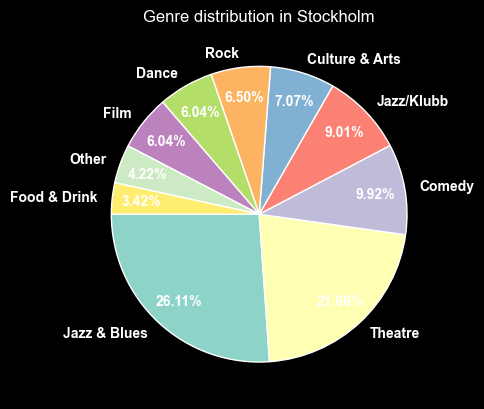

In [44]:
# Pie chart showing top 10 genre distribution
df['genre'].value_counts().head(10).plot(
    kind='pie',
    autopct='%2.2f%%',
    startangle=180,
    pctdistance=0.80,
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 10}
)

plt.title('Genre distribution in Stockholm', color='white')
plt.ylabel('')

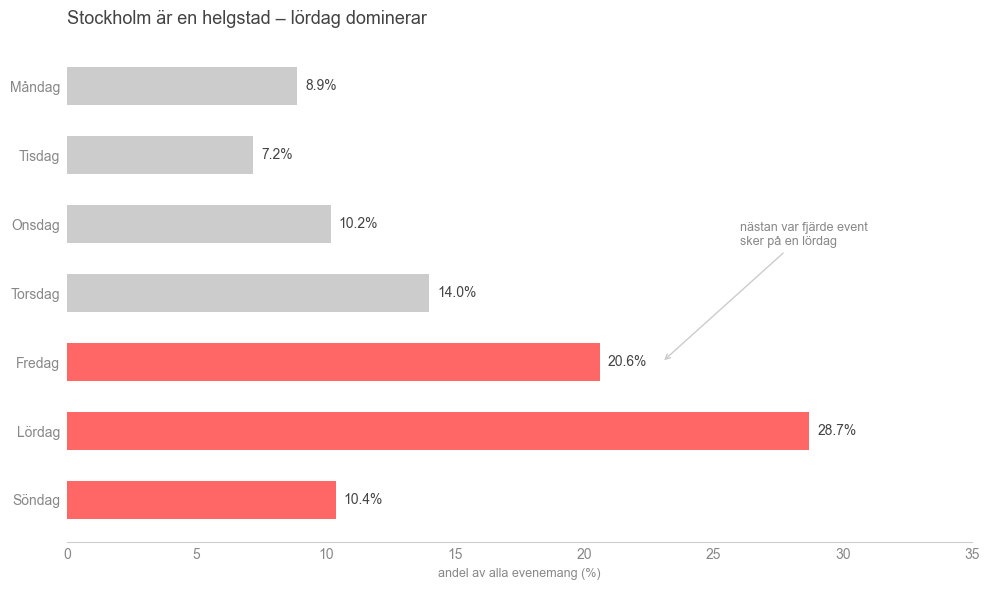

In [49]:
import matplotlib.pyplot as plt

BAKGRUND = '#FFFFFF'
KORALL = '#FF6666'
GRAY_1 = '#CCCCCC'
GRAY_2 = '#888888'
GRAY_3 = '#444444'
NORMAL = '#CCCCCC'

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Måndag', 'Tisdag', 'Onsdag', 'Torsdag', 'Fredag', 'Lördag', 'Söndag']

day_counts = df['day_of_week'].value_counts().reindex(day_order).fillna(0)
total = day_counts.sum()
pct = (day_counts / total * 100).round(1)

colors = [KORALL if day in ['Friday', 'Saturday', 'Sunday'] else NORMAL for day in day_order]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BAKGRUND)
ax.set_facecolor(BAKGRUND)

bars = ax.barh(day_labels[::-1], pct.values[::-1], color=colors[::-1], height=0.55, edgecolor='none')

for bar, val in zip(bars, pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', ha='left', color=GRAY_3, fontsize=10)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.tick_params(colors=GRAY_2, labelsize=10, length=0, pad=5)
ax.set_xlabel('andel av alla evenemang (%)', color=GRAY_2, fontsize=9)
ax.set_ylabel('')
ax.set_xlim(0, 35)

ax.set_title(
    'Stockholm är en helgstad – lördag dominerar',
    loc='left',
    color=GRAY_3,
    fontsize=13,
    pad=15
)

# lördag sticker ut rejält
ax.annotate(
    xy=(23, 2),
    text='nästan var fjärde event\nsker på en lördag',
    color=GRAY_2,
    fontsize=9,
    xytext=(26, 3.7),
    arrowprops=dict(arrowstyle='->', color=GRAY_1, lw=1)
)

fig.tight_layout()
fig.savefig('data_images/storytelling_weekend-activity.png', dpi=250, bbox_inches='tight', facecolor=BAKGRUND)

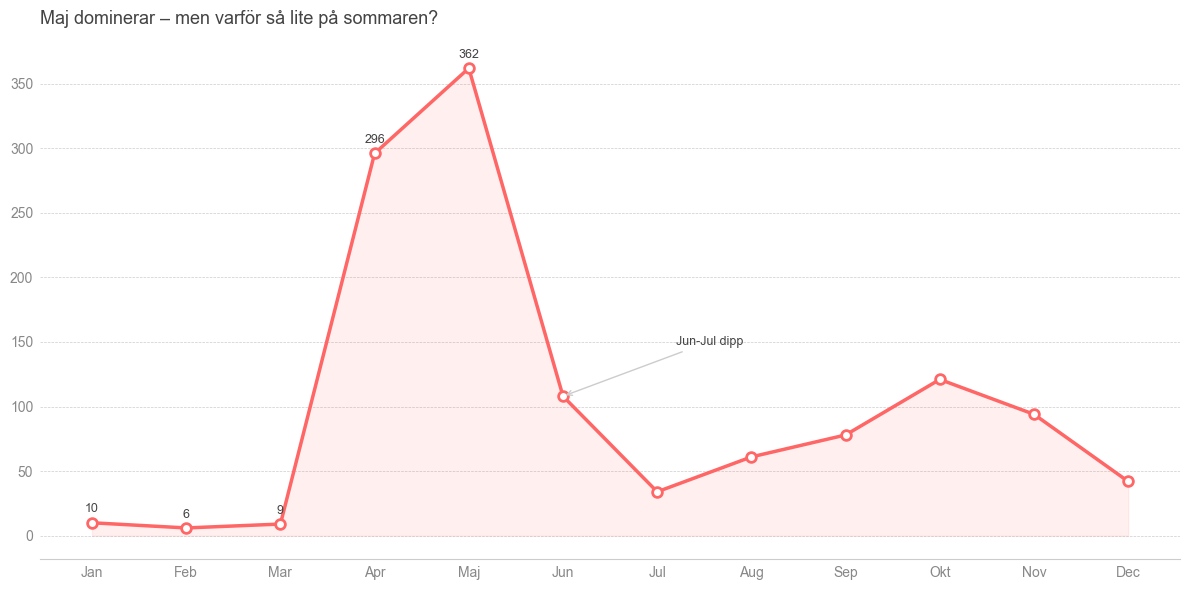

In [50]:
import matplotlib.pyplot as plt

BAKGRUND = '#FFFFFF'
KORALL = '#FF6666'
GRAY_1 = '#CCCCCC'
GRAY_2 = '#888888'
GRAY_3 = '#444444'

month_order = list(range(1, 13))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']

month_counts = df.groupby('month_num').size().reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BAKGRUND)
ax.set_facecolor(BAKGRUND)

ax.plot(month_labels, month_counts.values, color=KORALL, linewidth=2.5,
        marker='o', markersize=7, markerfacecolor='white',
        markeredgecolor=KORALL, markeredgewidth=2)
ax.fill_between(month_labels, month_counts.values, alpha=0.1, color=KORALL)

for i, val in enumerate(month_counts.values):
    if val > 200 or val < 20:
        ax.text(i, val + 8, str(int(val)), ha='center', color=GRAY_3, fontsize=9)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.tick_params(colors=GRAY_2, labelsize=10, length=0, pad=5)
ax.yaxis.grid(True, color=GRAY_1, linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

ax.set_title(
    'Maj dominerar – men varför så lite på sommaren?',
    loc='left',
    color=GRAY_3,
    fontsize=13,
    pad=15
)

# sommardipp verkar konstigt låg
ax.annotate(
    xy=(5, month_counts.values[5]),
    text='Jun-Jul dipp',
    color=GRAY_3,
    fontsize=9,
    xytext=(6.2, month_counts.values[5] + 40),
    arrowprops=dict(arrowstyle='->', color=GRAY_1, lw=1)
)

fig.tight_layout()
fig.savefig('data_images/storytelling_seasonal.png', dpi=250, bbox_inches='tight', facecolor=BAKGRUND)